
Decision Tree
Accuracy on training set = 0.40828138913624223
Accuracy on testing set  = 0.3756082048020353
Weighted F1 on training set = 0.4294690958226676
Weighted F1 on testing set  = 0.40206464710526746

Classification Report (test):
              precision    recall  f1-score   support

         1.0       0.25      0.47      0.33      1898
         2.0       0.11      0.26      0.16      1892
         3.0       0.16      0.19      0.17      3714
         4.0       0.28      0.30      0.29      7143
         5.0       0.66      0.45      0.54     16798

    accuracy                           0.38     31445
   macro avg       0.29      0.33      0.30     31445
weighted avg       0.46      0.38      0.40     31445



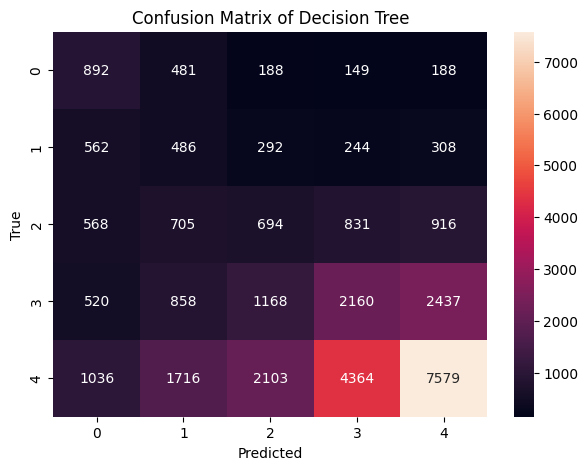


Random Forest
Accuracy on training set = 0.855054488402663
Accuracy on testing set  = 0.45418985530290984
Weighted F1 on training set = 0.8555020805507094
Weighted F1 on testing set  = 0.44917173456066556

Classification Report (test):
              precision    recall  f1-score   support

         1.0       0.34      0.45      0.39      1898
         2.0       0.15      0.16      0.15      1892
         3.0       0.17      0.16      0.16      3714
         4.0       0.27      0.23      0.25      7143
         5.0       0.63      0.65      0.64     16798

    accuracy                           0.45     31445
   macro avg       0.31      0.33      0.32     31445
weighted avg       0.45      0.45      0.45     31445



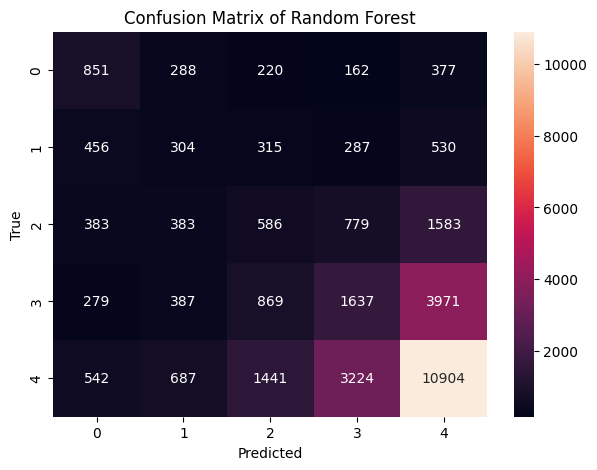


Best model: Random Forest


,Id,Score
0,1224650,5.0
1,1019381,5.0
2,504719,5.0
3,1622425,5.0
4,482286,5.0


In [1]:
from sklearn.model_selection import train_test_split

import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

from src.data import load_train_data, load_test_data
from src.features import prepare_training_data
from src.model import (
    train_decision_tree,
    train_random_forest,
    evaluate_model,
    save_model,
    create_submission
)

# Load data
trainingSet = load_train_data("../data/train.csv")
test_df = load_test_data("../data/test.csv")

# Prepare features
X, y = prepare_training_data(trainingSet)

# Split
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=0,
    stratify=y
)

# Train models
dt_model = train_decision_tree(X_train, Y_train)
rf_model = train_random_forest(X_train, Y_train)

# Evaluate
dt_f1 = evaluate_model(dt_model, X_train, X_test, Y_train, Y_test, title="Decision Tree")
rf_f1 = evaluate_model(rf_model, X_train, X_test, Y_train, Y_test, title="Random Forest")

# Pick best
if rf_f1 > dt_f1:
    best_model = rf_model
    best_name = "../notebooks/random_forest_model.obj"
    print("\nBest model: Random Forest")
else:
    best_model = dt_model
    best_name = "../notebooks/decision_tree_model.obj"
    print("\nBest model: Decision Tree")

save_model(best_model, best_name)

# Submission
submission = create_submission(best_model, test_df, X.columns, "../submissions/submission.csv")
submission.head()